**Задание на лабораторную работу №3**  
Улучшить изображение методами из лб №2 и лб №3

Загрузка и просмотр исходного изображенния

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


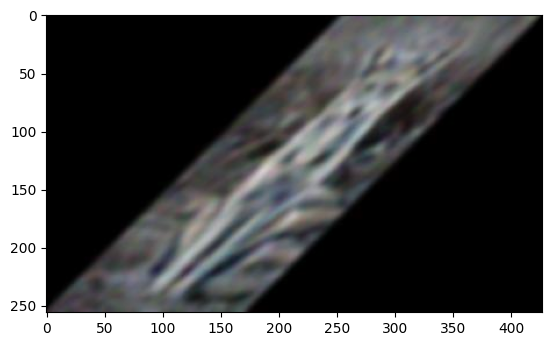

In [ ]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Image_processing/wolf.jpg'

image = cv2.imread(path, cv2.COLOR_BGR2RGB)

plt.imshow(image)

Геометрическое преобразование, сдвиг изображения

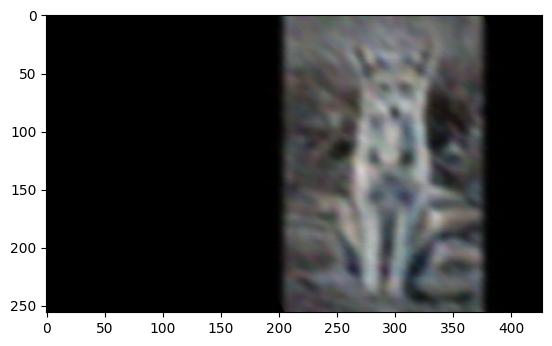

In [ ]:
rows, cols, q = image.shape

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[50,50],[200,50],[200,200]])

M = cv2.getAffineTransform(pts1,pts2)
shifted_image = cv2.warpAffine(image,M,(cols,rows))

plt.imshow(shifted_image)
plt.show()

Попытка образать черные границы изображения

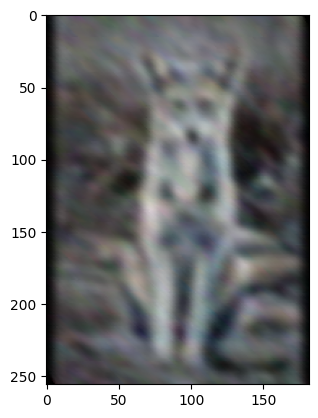

In [ ]:
gray = cv2.cvtColor(shifted_image,cv2.COLOR_BGR2GRAY)
_,thresh = cv2.threshold(gray,10,255,cv2.THRESH_BINARY)
contours,hierarchy = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

cnt = contours[0]
x,y,w,h = cv2.boundingRect(cnt)
cropped_image = shifted_image[y:y+h,x:x+w]

cv2.imwrite('/content/drive/MyDrive/Image_processing/cr_wolf.jpg' , cropped_image)

plt.imshow(cropped_image)
plt.show()

Гамма-коррекция изображения

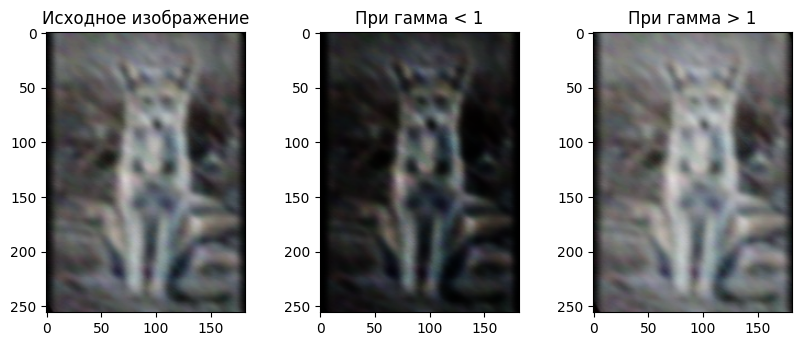

In [ ]:
path1 = '/content/drive/MyDrive/Image_processing/cr_wolf.jpg'

def gammaCorrection(src, gamma):
    invGamma = 1 / gamma

    table = [((i / 255) ** invGamma) * 255 for i in range(256)]
    table = np.array(table, np.uint8)

    return cv2.LUT(src, table)

cr_img = cv2.imread(path1)
gamma_1 = gammaCorrection(cr_img, 0.5)
gamma_2 = gammaCorrection(cr_img, 1.3)

plt.figure(figsize=(10, 8))

plt.subplot(2, 3, 1)
plt.title('Исходное изображение')
plt.imshow(cr_img)

plt.subplot(2, 3, 2)
plt.title('При гамма < 1')
plt.imshow(gamma_1)

plt.subplot(2, 3, 3)
plt.title('При гамма > 1')
plt.imshow(gamma_2)

Яркостная нормализация

/tmp/ipython-input-1382129187.py:19: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(cr_img.reshape(-1), 256, range)
/tmp/ipython-input-1382129187.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(res_image.reshape(-1), 256, range)


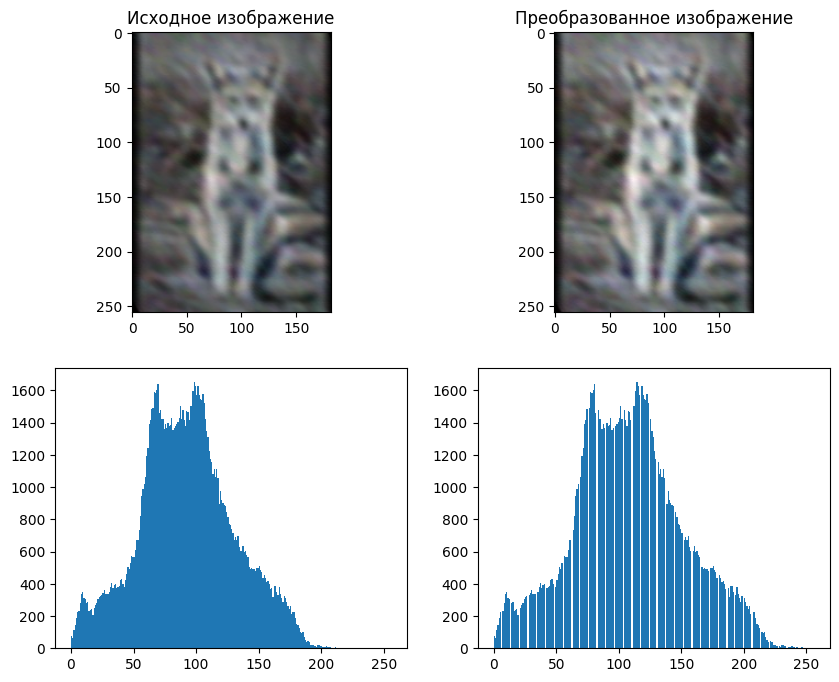

In [ ]:
range = [0, 256]

lut = lambda i: 255 * ((i - np.min(i)) / (np.max(i) - np.min(i)))
res_image = lut(cr_img).astype(np.uint8)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.title('Исходное изображение')
plt.imshow(cr_img)

plt.subplot(2, 2, 2)
plt.title('Преобразованное изображение')
plt.imshow(res_image)

#plt.imshow((out * 255).astype(np.uint8))

plt.subplot(2, 2, 3)
plt.hist(cr_img.reshape(-1), 256, range)
plt.subplot(2, 2, 4)
plt.hist(res_image.reshape(-1), 256, range)

plt.show()

CLAHE - коррекция

In [ ]:
def plot_rgb_hist(image, histSize, range):
    histSize = [256]
    range = [0, 256]
    for i, col in enumerate(['b', 'g', 'r']):
        hist = cv2.calcHist([image], [i], None, histSize, range)
        plt.plot(hist, color=col)
        plt.xlim(range)

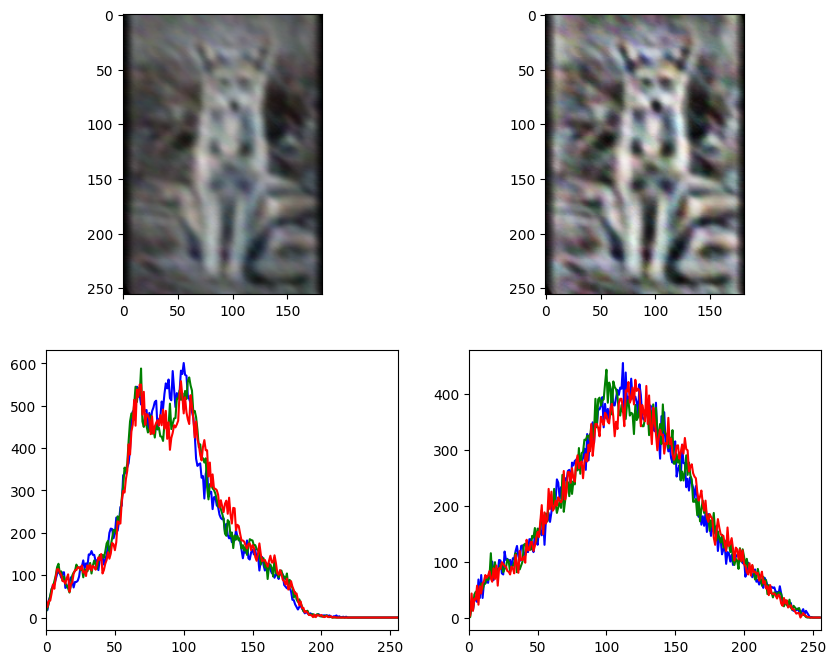

In [ ]:
histSize = [256]

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

rgb_result_image = np.empty(np.shape(cr_img), np.uint8)
rgb_result_image[:, :, 0] = clahe.apply(cr_img[:, :, 0])
rgb_result_image[:, :, 1] = clahe.apply(cr_img[:, :, 1])
rgb_result_image[:, :, 2] = clahe.apply(cr_img[:, :, 2])

gs = plt.GridSpec(2, 2)
plt.figure(figsize=(10, 8))

plt.subplot(gs[0])
plt.imshow(cr_img)

plt.subplot(gs[1])
plt.imshow(rgb_result_image)

plt.subplot(gs[2])
plot_rgb_hist(cr_img, histSize, range)

plt.subplot(gs[3])
plot_rgb_hist(rgb_result_image, histSize, range)

plt.show()

(ну как-то лучше не стало...)

Сглаживание изображения

In [ ]:
def add_gauss_noise(image, mean, sigma):
    image = np.array(image / 255, dtype=float)
    noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image + noise
    out = np.clip(noisy_image, 0, 1.0)
    out = np.uint8(out * 255)
    return out

In [ ]:
def getPSNR(I1, I2):
    s1 = cv2.absdiff(I1, I2)  #|I1 - I2| - модуль разницы двух изображений
    s1 = np.float32(s1)
    s1 = s1 * s1  # |I1 - I2|^2
    sse = s1.sum()  # сумма элементов в каждом канале
    if sse <= 1e-10:  # сумма каналов
        return 0
    else:
        shape = I1.shape
        p=1
        for i in shape:
          p *= i
        mse = 1.0 * sse /p
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr

In [ ]:
def getSSIM(i1, i2):
    C1 = 6.5025  # для 8-битного изоражения
    C2 = 58.5225  # для 8-битного изоражения
    # INITS
    I1 = np.float32(i1)
    I2 = np.float32(i2)
    I2_2 = I2 * I2  # I2^2
    I1_2 = I1 * I1  # I1^2
    I1_I2 = I1 * I2  # I1 * I2

    mu1 = cv2.GaussianBlur(I1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(I2, (11, 11), 1.5)
    mu1_2 = mu1 * mu1
    mu2_2 = mu2 * mu2
    mu1_mu2 = mu1 * mu2
    sigma1_2 = cv2.GaussianBlur(I1_2, (11, 11), 1.5)
    sigma1_2 -= mu1_2
    sigma2_2 = cv2.GaussianBlur(I2_2, (11, 11), 1.5)
    sigma2_2 -= mu2_2
    sigma12 = cv2.GaussianBlur(I1_I2, (11, 11), 1.5)
    sigma12 -= mu1_mu2
    t1 = 2 * mu1_mu2 + C1
    t2 = 2 * sigma12 + C2
    t3 = t1 * t2  # t3 = ((2*mu1_mu2 + C1).*(2*sigma12 + C2))
    t1 = mu1_2 + mu2_2 + C1
    t2 = sigma1_2 + sigma2_2 + C2
    t1 = t1 * t2  # t1 =((mu1_2 + mu2_2 + C1).*(sigma1_2 + sigma2_2 + C2))
    ssim_map = cv2.divide(t3, t1)  # ssim_map =  t3./t1;
    ssim = cv2.mean(ssim_map)  # mssim = average of ssim map
    ssim = ssim[:3]
    return ssim

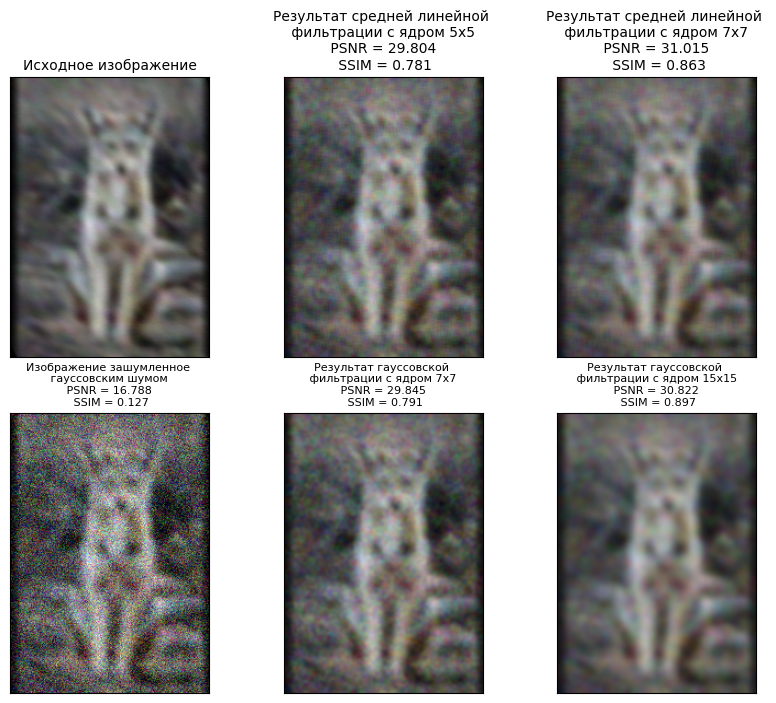

In [ ]:
kernel55 = np.ones((5, 5), np.float32) / 25
kernel77 = np.ones((7, 7), np.float32) / 49

# изображение на три канала (RGB)
channels = cv2.split(cr_img)

# гауссовский шум к каждому каналу
noisy_channels = [add_gauss_noise(channel, 0, 0.15) for channel in channels]

# линейная фильтрация к каждому каналу
filtered_channels1 = [cv2.filter2D(noisy_channel, -1, kernel55) for noisy_channel in noisy_channels]
filtered_channels2 = [cv2.filter2D(noisy_channel, -1, kernel77) for noisy_channel in noisy_channels]

# гауссовская фильтрация к каждому каналу
gaussian_channels1 = [cv2.GaussianBlur(noisy_channel, (7, 7), 0) for noisy_channel in noisy_channels]
gaussian_channels2 = [cv2.GaussianBlur(noisy_channel, (15, 15), 0) for noisy_channel in noisy_channels]

noisy_image = cv2.merge(noisy_channels)
filtered_image1 = cv2.merge(filtered_channels1)
filtered_image2 = cv2.merge(filtered_channels2)
gaussian_image1 = cv2.merge(gaussian_channels1)
gaussian_image2 = cv2.merge(gaussian_channels2)

# вывод
plt.figure(figsize=(10, 8))

plt.subplot(2, 3, 1)
plt.xticks([]), plt.yticks([])
plt.title('Исходное изображение', fontsize=10)
plt.imshow(cv2.cvtColor(cr_img, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 4)
plt.xticks([]), plt.yticks([])
psnr = getPSNR(cr_img, noisy_image)
ssim = getSSIM(cr_img, noisy_image)
plt.title(f'Изображение зашумленное \n гауссовским шумом \n PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}', fontsize=8)
plt.imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 2)
plt.xticks([]), plt.yticks([])
psnr = getPSNR(cr_img, filtered_image1)
ssim = getSSIM(cr_img, filtered_image1)
plt.title(f'Результат средней линейной \n фильтрации с ядром 5х5 \n PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}', fontsize=10)
plt.imshow(cv2.cvtColor(filtered_image1, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 3)
plt.xticks([]), plt.yticks([])
psnr = getPSNR(cr_img, filtered_image2)
ssim = getSSIM(cr_img, filtered_image2)
plt.title(f'Результат средней линейной \n фильтрации с ядром 7х7 \n PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}', fontsize=10)
plt.imshow(cv2.cvtColor(filtered_image2, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 5)
plt.xticks([]), plt.yticks([])
psnr = getPSNR(cr_img, gaussian_image1)
ssim = getSSIM(cr_img, gaussian_image1)
plt.title(f'Результат гауссовской \n фильтрации с ядром 7х7 \n PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}', fontsize=8)
plt.imshow(cv2.cvtColor(gaussian_image1, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 6)
plt.xticks([]), plt.yticks([])
psnr = getPSNR(cr_img, gaussian_image2)
ssim = getSSIM(cr_img, gaussian_image2)
plt.title(f'Результат гауссовской \n фильтрации с ядром 15х15 \n PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}', fontsize=8)
plt.imshow(cv2.cvtColor(gaussian_image2, cv2.COLOR_BGR2RGB))

plt.show()

Повышение резкости изображения

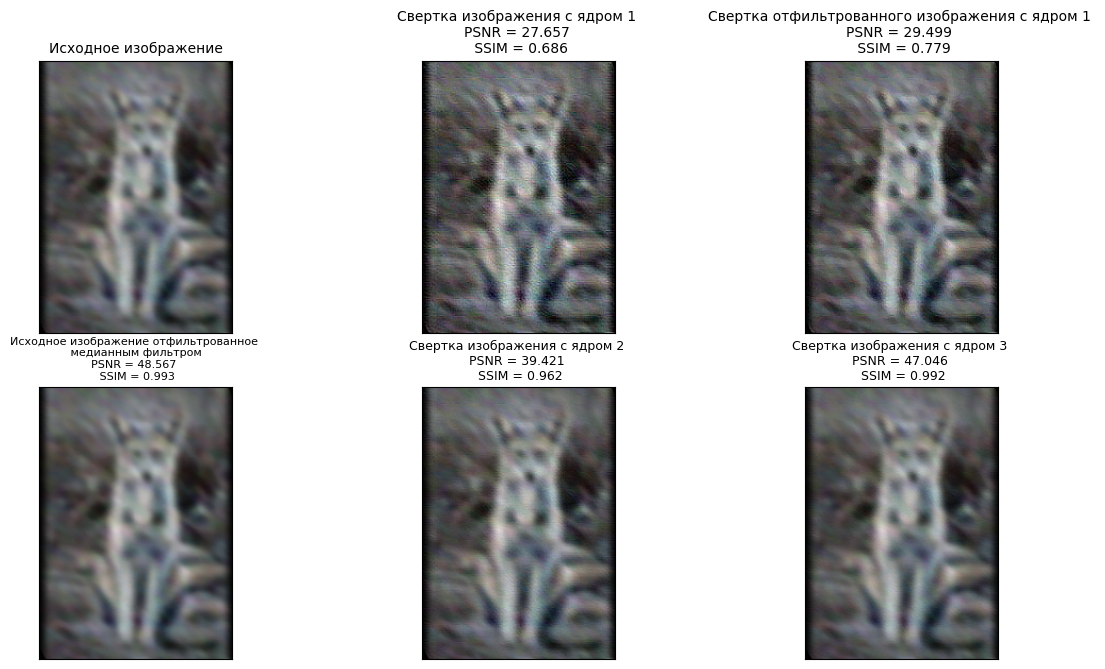

In [ ]:
kernel1 = np.asarray([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
kernel2 = np.asarray([[-0.25, -0.25, -0.25], [-0.25, 3, -0.25], [-0.25, -0.25, -0.25]])
kernel3 = np.asarray([[0, -0.25, 0], [-0.25, 2, -0.25], [0, -0.25, 0]])

image1_median = cv2.medianBlur(cr_img, 3)

filtered_image1 = cv2.filter2D(cr_img, -1, kernel1)
filtered_image1_median = cv2.filter2D(image1_median, -1, kernel1)
filtered_image2 = cv2.filter2D(cr_img, -1, kernel2)
filtered_image2_median = cv2.filter2D(image1_median, -1, kernel2)
filtered_image3 = cv2.filter2D(cr_img, -1, kernel3)
filtered_image3_median = cv2.filter2D(image1_median, -1, kernel3)

# вывод
plt.figure(figsize=(14, 12))

plt.subplot(331)
plt.xticks([]), plt.yticks([])
plt.title('Исходное изображение', fontsize=10)
plt.imshow(cr_img, cmap='gray')

plt.subplot(334)
plt.xticks([]), plt.yticks([])
plt.title(f'Исходное изображение отфильтрованное \n медианным фильтром \n'
          f'PSNR = {getPSNR(cr_img, image1_median):.3f} \n '
          f'SSIM = {getSSIM(cr_img, image1_median)[0]:.3f}', fontsize=8)
plt.imshow(image1_median, cmap='gray')

plt.subplot(332)
plt.xticks([]), plt.yticks([])
plt.title(f'Свертка изображения с ядром 1 \n'
          f'PSNR = {getPSNR(cr_img, filtered_image1):.3f} \n '
          f'SSIM = {getSSIM(cr_img, filtered_image1)[0]:.3f}', fontsize=10)
plt.imshow(filtered_image1, 'gray')

plt.subplot(333)
plt.xticks([]), plt.yticks([])
plt.title(f'Свертка отфильтрованного изображения с ядром 1 \n'
          f'PSNR = {getPSNR(cr_img, filtered_image1_median):.3f} \n '
          f'SSIM = {getSSIM(cr_img, filtered_image1_median)[0]:.3f}', fontsize=10)
plt.imshow(filtered_image1_median, 'gray')

plt.subplot(335)
plt.xticks([]), plt.yticks([])
plt.title(f'Свертка изображения с ядром 2 \n'
          f'PSNR = {getPSNR(cr_img, filtered_image2):.3f} \n '
          f'SSIM = {getSSIM(cr_img, filtered_image2)[0]:.3f}', fontsize=9)
plt.imshow(filtered_image2, 'gray')

plt.subplot(336)
plt.xticks([]), plt.yticks([])
plt.title(f'Свертка изображения с ядром 3 \n'
          f'PSNR = {getPSNR(cr_img, filtered_image3):.3f} \n '
          f'SSIM = {getSSIM(cr_img, filtered_image3)[0]:.3f}', fontsize=9)
plt.imshow(filtered_image3, 'gray')

plt.show()